# Ноутбук 01. Подготовка выборки и ключевая описательная статистика

### Блок 1. Импорт библиотек

In [3]:
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator
from pandas.util import hash_pandas_object
from textwrap import fill
from tqdm import tqdm

### Блок 2. Пути к локальным данным и файлам вывода

Датасет **FNSPID** (Financial News and Stock Price Integration Dataset) размещён на HuggingFace и скачивается из оригинального ноутбука по базовому [URL](https://huggingface.co/datasets/Zihan1004/FNSPID)

Авторы датасета — Zihan Dong, Xinyu Fan, Zhiyuan Peng. Датасет покрывает период 1999 - 2023 гг. и объединяет новостные статьи, привязанные к тикерам американских компаний, с дневными ценовыми данными по тем же тикерам.

Датасет организован в две папки, и из каждой скачиваются свои файлы:

**`Stock_news/`** — новостной корпус. Содержит два CSV-файла:

- **`All_external.csv`** — основной файл с новостями. Каждая строка — одна статья: дата публикации, тикер компании, заголовок, URL, автор, а также четыре варианта автоматических саммари (LSA, Luhn, TextRank, LexRank). Это файл с более высоким заполнением текстовых полей, поэтому при дедупликации он используется как приоритетный источник.
- **`nasdaq_exteral_data.csv`** — вспомогательный файл с новостями из того же источника (NASDAQ). Структура колонок та же. Он частично дублирует `All_external.csv`, но содержит дополнительные записи. Именно поэтому в ноутбуке выполняется дедупликация по хешу комбинации (тикер + URL) или (тикер + дата + заголовок), и из суммарных 15,5 млн строк остаётся 1,23 млн уникальных статей.

**`Stock_price/`** — ценовые данные. Содержит один архив:

- **`full_history.zip`** - при распаковке создаёт папку `full_history/full_history/`, внутри которой лежит по одному CSV-файлу на каждый тикер (например, `TSLA.csv`, `AAPL.csv` и т.д.). Каждый файл содержит дневные данные: дата, цена открытия, закрытия, скорректированная цена закрытия (adjusted close) и объём торгов. Всего в архиве 7 691 тикер.

В данной версии убран блок скачивания — ноутбук предполагает, что файлы `All_external.csv`, `nasdaq_exteral_data.csv` и папка `full_history/full_history/` уже лежат локально. Функция `ensure_local_inputs()` просто проверяет их наличие и выбрасывает ошибку, если чего-то нет. Метаданные Yahoo Finance (сектор, биржа, quoteType) тоже не загружаются заново, а берутся из кэша `ticker_meta_yahoo.csv`.
Для скачивания данных с нуля в репозитории можно использовать ноутбук `FNSPID_download.ipynb`

In [4]:
OUTPUT_DIR = "outputs_01"
DATA_DIR = "full_history/full_history"
NEWS_FILES = ["All_external.csv", "nasdaq_exteral_data.csv"]

START_DATE = pd.Timestamp("2019-01-01")
END_DATE = pd.Timestamp("2023-12-31")

EDGE_TOLERANCE_DAYS = 31
THRESHOLD_PRICE_ROWS = 1000
THRESHOLD_NEWS_COUNT = 50
THRESHOLD_COVERAGE_PCT = 80
CHUNKSIZE = 200000

def out_path(name):
    return os.path.join(OUTPUT_DIR, name)

os.makedirs(OUTPUT_DIR, exist_ok=True)

NEWS_DEDUPED = out_path("news_deduped_2019_2023.csv")
META_CACHE = out_path("ticker_meta_yahoo.csv")
PRICE_CACHE = out_path("cache_price_coverage_2019_2023.csv")
NEWS_CACHE = out_path("cache_news_stats_2019_2023.csv")

QUALITY_REPORT_PATH = out_path("data_quality_report.csv")
SELECTED_COMPANIES_PATH = out_path("selected_companies_2019_2023.csv")
SELECTED_EQUITIES_PATH = out_path("selected_equities_only_2019_2023.csv")
SELECTED_TICKERS_PATH = out_path("selected_tickers.csv")

FIG_COMPANIES_BY_SECTOR_BASE = out_path("fig_companies_by_sector_ieee")
FIG_NEWS_BY_SECTOR_BASE = out_path("fig_news_by_sector_ieee")
FIG_NEWS_CONCENTRATION_BASE = out_path("fig_news_concentration_ieee")
FIG_COMPANIES_BY_EXCHANGE_BASE = out_path("fig_companies_by_exchange_ieee")
FIG_TSLA_BASE = out_path("fig_tsla_oct2023")

PRICES_RETURNS_PATH = out_path("prices_returns_2019_2023.parquet")
MASTER_PATH = out_path("returns_sentiment_enhanced.parquet")
TSLA_EVENT_TABLE_PATH = out_path("tsla_oct2023_event_table.csv")

### Блок 3. Вспомогательные функции

Функции для локальной дедупликации новостей, анализа покрытия цен, применения фильтров качества и загрузки уже сохранённых метаданных

In [5]:
def print_step(title):
    line = "=" * 60
    print(line)
    print(title)
    print(line)

def ensure_local_inputs():
    missing = []

    if not os.path.isdir(DATA_DIR):
        missing.append(DATA_DIR)

    for name in NEWS_FILES:
        if not os.path.exists(name):
            missing.append(name)

    if missing:
        msg = "\n".join(missing)
        raise FileNotFoundError(f"Не найдены локальные исходники:\n{msg}")

def load_metadata_cache(path):
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        raise FileNotFoundError(
            f"Не найден локальный кэш метаданных: {path}. "
            "Для этого ноутбука данные заново не скачиваются."
        )

    meta = pd.read_csv(path, low_memory=False)

    for col in ["ticker", "company_name", "sector", "industry", "exchange", "quoteType"]:
        if col not in meta.columns:
            meta[col] = np.nan

    meta["ticker"] = meta["ticker"].astype(str).str.strip()

    return (
        meta[["ticker", "company_name", "sector", "industry", "exchange", "quoteType"]]
        .drop_duplicates(subset=["ticker"], keep="last")
        .reset_index(drop=True)
    )

def aggregate_news_statistics(file_paths, valid_tickers, chunksize=200_000):
    counts = {}
    min_dates = {}
    max_dates = {}
    tickers_set = set(map(str, valid_tickers))

    for filepath in file_paths:
        tag = os.path.basename(filepath)

        try:
            reader = pd.read_csv(
                filepath,
                chunksize=chunksize,
                usecols=["Date", "Stock_symbol"],
                low_memory=False,
            )
        except Exception:
            reader = pd.read_csv(filepath, chunksize=chunksize, low_memory=False)

        for chunk in tqdm(reader, desc=f"Обработка {tag}"):
            if "Date" in chunk.columns:
                chunk = chunk.rename(columns={"Date": "date"})
            if "Stock_symbol" in chunk.columns:
                chunk = chunk.rename(columns={"Stock_symbol": "ticker"})

            if "date" not in chunk.columns or "ticker" not in chunk.columns:
                continue

            chunk["date"] = (
                pd.to_datetime(chunk["date"], errors="coerce", utc=True)
                .dt.tz_convert(None)
                .dt.normalize()
            )
            chunk = chunk.dropna(subset=["date", "ticker"])
            chunk = chunk[(chunk["date"] >= START_DATE) & (chunk["date"] <= END_DATE)]
            chunk["ticker"] = chunk["ticker"].astype(str).str.strip()
            chunk = chunk[chunk["ticker"].isin(tickers_set)]

            if chunk.empty:
                continue

            grouped = chunk.groupby("ticker")["date"].agg(["count", "min", "max"])

            for ticker, row in grouped.iterrows():
                counts[ticker] = counts.get(ticker, 0) + int(row["count"])
                min_dates[ticker] = row["min"] if ticker not in min_dates else min(min_dates[ticker], row["min"])
                max_dates[ticker] = row["max"] if ticker not in max_dates else max(max_dates[ticker], row["max"])

    return pd.DataFrame(
        {
            "ticker": list(counts.keys()),
            "news_count": [counts[t] for t in counts],
            "news_min_date": [min_dates[t] for t in counts],
            "news_max_date": [max_dates[t] for t in counts],
        }
    )

def get_expected_market_dates(data_dir, start, end, reference_ticker="SPY"):
    ref_fp = os.path.join(data_dir, f"{reference_ticker}.csv")

    if os.path.exists(ref_fp):
        try:
            df = pd.read_csv(ref_fp, usecols=["date"], low_memory=False)
            d = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
            d = d.dropna()
            d = d[(d >= start) & (d <= end)]

            if len(d) > 0:
                return pd.DatetimeIndex(np.sort(d.unique()))
        except Exception:
            pass

    return pd.bdate_range(start, end).normalize()

def analyze_price_coverage(data_dir, start, end, expected_dates, edge_tolerance_days=31, max_errors=10):
    expected_dates = pd.DatetimeIndex(expected_dates).sort_values()
    expected_days = int(len(expected_dates))
    files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]

    results = []
    errors = []

    for filename in tqdm(files, desc="Анализ покрытия цен"):
        ticker = filename[:-4]

        try:
            fp = os.path.join(data_dir, filename)
            df = pd.read_csv(fp, usecols=["date"], low_memory=False)
            df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
            df = df.dropna(subset=["date"])
            df = df[(df["date"] >= start) & (df["date"] <= end)]

            if df.empty:
                continue

            df = df.drop_duplicates(subset=["date"])
            dates = pd.DatetimeIndex(df["date"].values).sort_values()

            n_days = int(len(dates))
            date_min = dates[0]
            date_max = dates[-1]
            coverage = n_days / expected_days * 100 if expected_days > 0 else np.nan
            starts_ok = date_min <= (start + pd.Timedelta(days=edge_tolerance_days))
            ends_ok = date_max >= (end - pd.Timedelta(days=edge_tolerance_days))

            results.append(
                {
                    "ticker": ticker,
                    "price_rows": n_days,
                    "price_min_date": date_min,
                    "price_max_date": date_max,
                    "coverage_pct": round(float(coverage), 1) if np.isfinite(coverage) else np.nan,
                    "starts_in_2019": bool(starts_ok),
                    "ends_in_2023": bool(ends_ok),
                    "full_coverage": bool(starts_ok and ends_ok),
                }
            )
        except Exception as exc:
            if len(errors) < max_errors:
                errors.append((ticker, str(exc)))

    if errors:
        print(f"Ошибки чтения: {len(errors)}")
        for ticker, message in errors[:max_errors]:
            print(f"  - {ticker}: {message}")

    return pd.DataFrame(results)

def apply_quality_filters(df, min_rows, min_news, min_coverage):
    return (
        df["full_coverage"]
        & (df["price_rows"] >= min_rows)
        & (df["news_count"] >= min_news)
        & (df["coverage_pct"] >= min_coverage)
    )

def print_summary(df, title):
    line = "=" * 60
    print()
    print(line)
    print(title)
    print(line)
    print(f"Количество компаний: {len(df)}")
    print(f"Период: {START_DATE.date()} — {END_DATE.date()}")

    if len(df) > 0 and "price_rows" in df.columns:
        print(f"Среднее число торговых дней: {df['price_rows'].mean():.0f}")
        print(f"Минимум / максимум торговых дней: {df['price_rows'].min():.0f} / {df['price_rows'].max():.0f}")

    if len(df) > 0 and "news_count" in df.columns:
        print(
            f"Новости на компанию: среднее {df['news_count'].mean():.0f}, "
            f"медиана {df['news_count'].median():.0f}, "
            f"диапазон [{df['news_count'].min()}, {df['news_count'].max()}]"
        )

def deduplicate_news_files(file_paths, output_path, chunksize=200_000):
    if os.path.exists(output_path) and os.path.getsize(output_path) > 0:
        print(f"Дедуплицированный файл уже существует: {output_path}")
        return output_path

    text_fields = [
        "Article_title",
        "Article",
        "Lsa_summary",
        "Luhn_summary",
        "Textrank_summary",
        "Lexrank_summary",
    ]

    def hash_chunk(df):
        if "Stock_symbol" not in df.columns:
            return pd.Series([], dtype="uint64")

        ticker = df["Stock_symbol"].astype(str).str.strip().str.upper()

        if "Url" in df.columns:
            url = df["Url"].astype(str).str.strip().str.lower()
            url = url.replace({"nan": "", "none": ""})
        else:
            url = pd.Series("", index=df.index, dtype="string")

        has_url = url.astype(str).str.len().fillna(0).astype(int) > 0
        d = pd.Series("", index=df.index, dtype="string")

        if "Date" in df.columns:
            mask = ~has_url
            if mask.any():
                dd = pd.to_datetime(df.loc[mask, "Date"], errors="coerce", utc=True).dt.tz_convert(None).dt.normalize()
                d.loc[mask] = dd.dt.strftime("%Y-%m-%d").fillna("")

        title = pd.Series("", index=df.index, dtype="string")

        if "Article_title" in df.columns:
            title = (
                df["Article_title"]
                .astype(str)
                .str.strip()
                .str.lower()
                .replace({"nan": "", "none": ""})
            )

        fallback = d.astype(str) + "||" + title.astype(str) + "||" + ticker.astype(str)
        key = np.where(has_url.values, (url.astype(str) + "||" + ticker.astype(str)).values, fallback.values)

        return hash_pandas_object(pd.Series(key), index=False).astype("uint64")

    fill_scores = {}

    for filepath in file_paths:
        tag = os.path.basename(filepath)
        filled_sum = 0
        n_rows = 0
        usecols = ["Stock_symbol", "Url"] + text_fields

        try:
            reader = pd.read_csv(filepath, chunksize=chunksize, usecols=lambda c: c in usecols, low_memory=False)
        except Exception:
            reader = pd.read_csv(filepath, chunksize=chunksize, low_memory=False)

        for chunk in tqdm(reader, desc=f"Сканирование {tag}"):
            n_rows += len(chunk)
            for col in text_fields:
                if col in chunk.columns:
                    filled_sum += int(chunk[col].notna().sum())

        mean_fill = filled_sum / max(n_rows, 1)
        fill_scores[filepath] = mean_fill
        print(f"{tag}: {n_rows:,} строк, среднее число заполненных текстовых полей {mean_fill:.2f}")

    preferred = max(file_paths, key=lambda p: fill_scores.get(p, 0.0))
    ordered = [preferred] + [p for p in file_paths if p != preferred]

    header_written = False
    total_written = 0
    seen = set()

    for filepath in ordered:
        tag = os.path.basename(filepath)

        for chunk in tqdm(pd.read_csv(filepath, chunksize=chunksize, low_memory=False), desc=f"Запись {tag}"):
            h = hash_chunk(chunk).values

            if len(h) == 0:
                continue

            mask = ~pd.Series(h).isin(seen).values

            if not mask.any():
                continue

            seen.update(h[mask].tolist())
            out_chunk = chunk.loc[mask]
            out_chunk.to_csv(output_path, mode="a", index=False, header=not header_written)
            header_written = True
            total_written += int(len(out_chunk))

    print(f"Готово: {total_written:,} строк записано в {output_path}")
    return output_path

### Блок 4. Локальная подготовка новостей

Ноутбук проверяет наличие локальных исходников и, если нужно, строит дедуплицированный файл новостей без повторной загрузки источников

In [6]:
print_step("Шаг 0. Проверка локальных исходников")

ensure_local_inputs()
NEWS_DEDUPED = deduplicate_news_files(NEWS_FILES, NEWS_DEDUPED, chunksize=CHUNKSIZE)

print(f"Используется файл новостей: {NEWS_DEDUPED}")

Шаг 0. Проверка локальных исходников
Дедуплицированный файл уже существует: outputs_01/news_deduped_2019_2023.csv
Используется файл новостей: outputs_01/news_deduped_2019_2023.csv


### Блок 5. Формирование итоговой выборки компаний

Здесь строится выборка компаний: сначала оценивается покрытие цен, затем считается число новостей, после чего применяются фильтры качества и присоединяются уже сохранённые метаданные

In [7]:
print_step("Шаг 1. Анализ ценового покрытия")

expected_dates = get_expected_market_dates(DATA_DIR, START_DATE, END_DATE, reference_ticker="SPY")

if os.path.exists(PRICE_CACHE):
    price_data = pd.read_csv(PRICE_CACHE, parse_dates=["price_min_date", "price_max_date"])
else:
    price_data = analyze_price_coverage(
        DATA_DIR,
        START_DATE,
        END_DATE,
        expected_dates,
        edge_tolerance_days=EDGE_TOLERANCE_DAYS,
    )
    price_data.to_csv(PRICE_CACHE, index=False)

print_step("Шаг 2. Агрегация статистики новостей")

valid_tickers = set(price_data["ticker"].astype(str))

if os.path.exists(NEWS_CACHE):
    news_data = pd.read_csv(NEWS_CACHE, parse_dates=["news_min_date", "news_max_date"])
else:
    news_data = aggregate_news_statistics([NEWS_DEDUPED], valid_tickers, chunksize=CHUNKSIZE)
    news_data.to_csv(NEWS_CACHE, index=False)

print_step("Шаг 3. Объединение и фильтрация")

combined = price_data.merge(news_data, on="ticker", how="inner")
combined["passes_filters"] = apply_quality_filters(
    combined,
    THRESHOLD_PRICE_ROWS,
    THRESHOLD_NEWS_COUNT,
    THRESHOLD_COVERAGE_PCT,
)

filtered = combined[combined["passes_filters"]].sort_values("news_count", ascending=False)

print_step("Шаг 4. Присоединение локальных метаданных")

metadata = load_metadata_cache(META_CACHE)

final_dataset = filtered.merge(
    metadata[["ticker", "company_name", "sector", "industry", "exchange", "quoteType"]],
    on="ticker",
    how="left",
)

output_columns = [
    "ticker",
    "company_name",
    "sector",
    "industry",
    "exchange",
    "quoteType",
    "price_rows",
    "price_min_date",
    "price_max_date",
    "coverage_pct",
    "starts_in_2019",
    "ends_in_2023",
    "full_coverage",
    "news_count",
    "news_min_date",
    "news_max_date",
]

final_dataset = final_dataset[output_columns].reset_index(drop=True)

quality_report = pd.DataFrame(
    [
        ["Тикеры с ценами в периоде", len(price_data)],
        ["Тикеры с полным покрытием цен", int(price_data["full_coverage"].sum())],
        ["Тикеры с новостями в периоде", len(news_data)],
        ["Тикеры после объединения", len(combined)],
        ["Тикеры после фильтров качества", int(combined["passes_filters"].sum())],
        ["Итоговая выборка", len(final_dataset)],
        ["Итоговая выборка: только EQUITY", int((final_dataset["quoteType"] == "EQUITY").sum())],
    ],
    columns=["Этап", "Количество"],
)

quality_report.to_csv(QUALITY_REPORT_PATH, index=False)
quality_report

Шаг 1. Анализ ценового покрытия
Шаг 2. Агрегация статистики новостей
Шаг 3. Объединение и фильтрация
Шаг 4. Присоединение локальных метаданных


,Этап,Количество
0,Тикеры с ценами в периоде,7691
1,Тикеры с полным покрытием цен,4068
2,Тикеры с новостями в периоде,5790
3,Тикеры после объединения,5790
4,Тикеры после фильтров качества,2804
5,Итоговая выборка,2804
6,Итоговая выборка: только EQUITY,2054


### Блок 6. Сохранение основных таблиц

In [8]:
final_dataset.to_csv(SELECTED_COMPANIES_PATH, index=False)

equities = final_dataset[final_dataset["quoteType"] == "EQUITY"].copy()
equities.to_csv(SELECTED_EQUITIES_PATH, index=False)

pd.DataFrame({"ticker": final_dataset["ticker"]}).to_csv(SELECTED_TICKERS_PATH, index=False)

print_summary(final_dataset, "СВОДКА ПО ИТОГОВОЙ ВЫБОРКЕ")
print(f"Сохранено: {SELECTED_COMPANIES_PATH}")
print(f"Сохранено: {SELECTED_EQUITIES_PATH}")
print(f"Сохранено: {SELECTED_TICKERS_PATH}")


СВОДКА ПО ИТОГОВОЙ ВЫБОРКЕ
Количество компаний: 2804
Период: 2019-01-01 — 2023-12-31
Среднее число торговых дней: 1256
Минимум / максимум торговых дней: 1007 / 1257
Новости на компанию: среднее 552, медиана 230, диапазон [50, 10587]
Сохранено: outputs_01/selected_companies_2019_2023.csv
Сохранено: outputs_01/selected_equities_only_2019_2023.csv
Сохранено: outputs_01/selected_tickers.csv


### Блок 7. Общий стиль рисунков IEEE

Здесь задаётся единый стиль рисунков и подготавливаются общие функции сохранения в `PDF` и `PNG`

In [9]:
IEEE_FONT = "Times New Roman"

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": [IEEE_FONT, "Times", "DejaVu Serif"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "figure.dpi": 150,
        "savefig.dpi": 600,
    }
)

FIG_W = 3.5
BAR_COLOR = "0.55"
EDGE_COLOR = "0.15"

def save_both(fig, base_path):
    fig.savefig(f"{base_path}.pdf", bbox_inches="tight")
    fig.savefig(f"{base_path}.png", bbox_inches="tight", dpi=600)

def wrap_labels(labels, width=16):
    return [fill(str(x), width=width) for x in labels]

def ieee_barh(series, xlabel, ylabel, base_path, height=2.6, wrap_width=18):
    fig, ax = plt.subplots(figsize=(FIG_W, height))
    labels = wrap_labels(series.index.tolist(), width=wrap_width)

    ax.barh(labels, series.values, color=BAR_COLOR, edgecolor=EDGE_COLOR, linewidth=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="x", linestyle=":", linewidth=0.5, color="0.80")
    ax.tick_params(direction="in")

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

    fig.tight_layout(pad=0.2)
    save_both(fig, base_path)
    plt.show()

companies = pd.read_csv(SELECTED_EQUITIES_PATH, low_memory=False)
companies.columns = [str(c).strip() for c in companies.columns]
companies["sector_clean"] = companies["sector"].fillna("Unknown")
companies["exchange_clean"] = companies["exchange"].fillna("Unknown")
companies["news_count"] = pd.to_numeric(companies["news_count"], errors="coerce").fillna(0)

### Блок 8. Число компаний по секторам

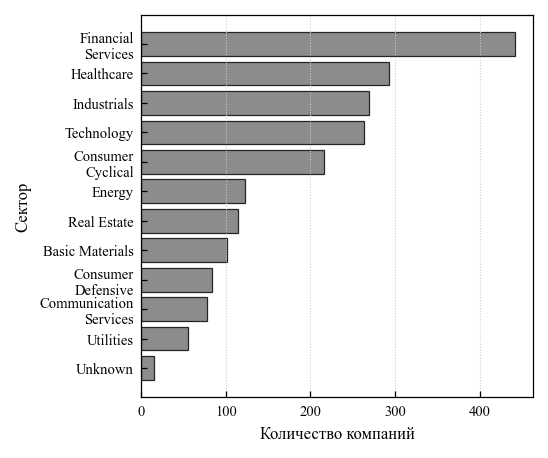

In [10]:
companies_by_sector = (
    companies.groupby("sector_clean")["ticker"]
    .nunique()
    .sort_values(ascending=True)
)

ieee_barh(
    companies_by_sector,
    xlabel="Количество компаний",
    ylabel="Сектор",
    base_path=FIG_COMPANIES_BY_SECTOR_BASE,
    height=2.9,
    wrap_width=16,
)

### Блок 9. Число новостей по секторам

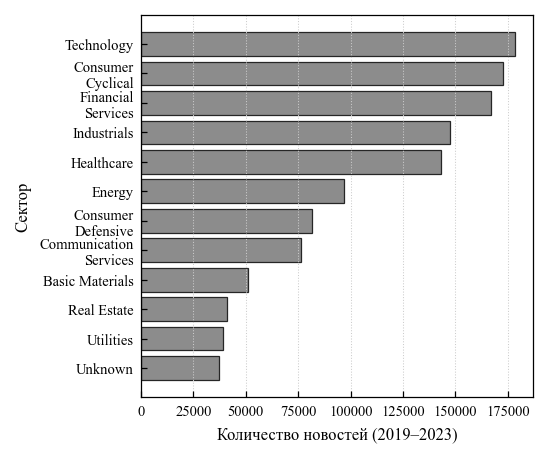

In [11]:
news_by_sector = (
    companies.groupby("sector_clean")["news_count"]
    .sum()
    .sort_values(ascending=True)
)

ieee_barh(
    news_by_sector,
    xlabel="Количество новостей (2019–2023)",
    ylabel="Сектор",
    base_path=FIG_NEWS_BY_SECTOR_BASE,
    height=2.9,
    wrap_width=16,
)

### Блок 10. Концентрация новостей по компаниям

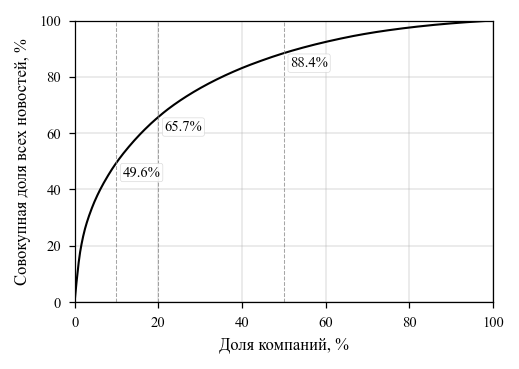

In [12]:
sorted_news = np.sort(companies["news_count"].values)[::-1]
cumsum = np.cumsum(sorted_news)
cumsum_pct = cumsum / cumsum[-1] * 100
companies_pct = np.arange(1, len(sorted_news) + 1) / len(sorted_news) * 100

fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.plot(companies_pct, cumsum_pct, color="black", linewidth=1.0)

for pct in [10, 20, 50]:
    idx = min(int(len(sorted_news) * pct / 100), len(sorted_news) - 1)
    ax.axvline(pct, color="gray", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.text(
        pct + 1.5,
        cumsum_pct[idx] - 5,
        f"{cumsum_pct[idx]:.1f}%",
        fontsize=7,
        bbox=dict(
            facecolor="white",
            edgecolor="lightgray",
            boxstyle="round,pad=0.15",
            linewidth=0.3,
            alpha=0.9,
        ),
    )

ax.set_xlabel("Доля компаний, %")
ax.set_ylabel("Совокупная доля всех новостей, %")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_both(fig, FIG_NEWS_CONCENTRATION_BASE)
plt.show()

### Блок 11. Охват компаний по биржам

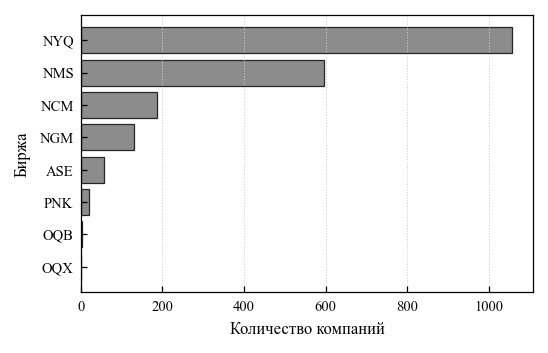

In [13]:
companies_by_exchange = (
    companies.groupby("exchange_clean")["ticker"]
    .nunique()
    .sort_values(ascending=True)
)

ieee_barh(
    companies_by_exchange,
    xlabel="Количество компаний",
    ylabel="Биржа",
    base_path=FIG_COMPANIES_BY_EXCHANGE_BASE,
    height=2.2,
    wrap_width=10,
)